## Activation Clustering

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, Subset

import numpy as np

import os

import math

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

from src.model import SmallCNN, MidCNN, LargeCNN

from tqdm import tqdm

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, precision_score, recall_score, f1_score,
    confusion_matrix
)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

import pandas as pd

import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams['figure.dpi'] = 115
plt.rcParams['font.size']  = 10

print(f"✅ Device: {device}")
print("✅ All libraries loaded")

✅ Device: cpu
✅ All libraries loaded


## Step 1 - Load normal MNIST Dataset

In [2]:
MEAN = 0.1307
STD  = 0.3081

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MEAN,), (STD,))
])

train_raw = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_raw  = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_raw, batch_size=64, shuffle=True)
test_loader = DataLoader(test_raw, batch_size=1000, shuffle=False)

## Step 2 - Initialize Model for Reconstruction

In [4]:
# class InstrumentedCNN(nn.Module):
#     """
#     CNN with hooks on every activation layer.
#     Layers are explicitly named for interpretability.

#     Architecture:
#       conv1 (1→32)  → bn1 → relu1 → pool1       [spatial: 28→14]
#       conv2 (32→64) → bn2 → relu2               [spatial: 14→14]
#       conv3 (64→64) → bn3 → relu3 → pool2       [spatial: 14→7]
#       conv4 (64→128)→ bn4 → relu4               [spatial: 7→7]
#       flatten → fc1 (128*7*7→256) → relu_fc1
#               → fc2 (256→128)      → relu_fc2
#               → fc3 (128→10)       [logits]
#     """
#     def __init__(self):
#         super().__init__()

#         # --- Convolutional blocks ---
#         self.conv1   = nn.Conv2d(1,  32, 3, padding=1)
#         self.bn1     = nn.BatchNorm2d(32)
#         self.conv2   = nn.Conv2d(32, 64, 3, padding=1)
#         self.bn2     = nn.BatchNorm2d(64)
#         self.conv3   = nn.Conv2d(64, 64, 3, padding=1)
#         self.bn3     = nn.BatchNorm2d(64)
#         self.conv4   = nn.Conv2d(64, 128, 3, padding=1)
#         self.bn4     = nn.BatchNorm2d(128)
#         self.pool    = nn.MaxPool2d(2, 2)
#         self.dropout = nn.Dropout(0.3)

#         # --- Fully connected layers ---
#         self.fc1 = nn.Linear(128 * 7 * 7, 256)
#         self.fc2 = nn.Linear(256, 128)
#         self.fc3 = nn.Linear(128, 10)

#         # --- Hook storage ---
#         # Maps layer_name → activation tensor (averaged over batch)
#         self._activations = {}
#         self._hooks        = []

#         # Layer registry (name → module) — used for hook registration
#         self.LAYER_REGISTRY = {
#             'conv1':    self.conv1,
#             'bn1':      self.bn1,
#             'conv2':    self.conv2,
#             'bn2':      self.bn2,
#             'conv3':    self.conv3,
#             'bn3':      self.bn3,
#             'conv4':    self.conv4,
#             'bn4':      self.bn4,
#             'fc1':      self.fc1,
#             'fc2':      self.fc2,
#         }

#         self._register_all_hooks()

#     # ------------------------------------------------------------------ #
#     def _register_all_hooks(self):
#         for name, module in self.LAYER_REGISTRY.items():
#             hook = module.register_forward_hook(self._make_hook(name))
#             self._hooks.append(hook)

#     def _make_hook(self, name):
#         def hook_fn(module, input, output):
#             self._activations[name] = output.detach().cpu()
#         return hook_fn

#     def remove_hooks(self):
#         for h in self._hooks:
#             h.remove()

#     # ------------------------------------------------------------------ #
#     def forward(self, x):
#         x = F.relu(self.bn1(self.conv1(x)))
#         x = self.pool(x)
#         x = F.relu(self.bn2(self.conv2(x)))
#         x = F.relu(self.bn3(self.conv3(x)))
#         x = self.pool(x)
#         x = F.relu(self.bn4(self.conv4(x)))
#         x = x.view(x.size(0), -1)
#         x = F.relu(self.fc1(self.dropout(x)))
#         x = F.relu(self.fc2(self.dropout(x)))
#         return self.fc3(x)

#     def get_activations(self):
#         """Return a copy of all stored activations."""
#         return {k: v.clone() for k, v in self._activations.items()}


# # ---- Layer metadata for display ----
# LAYER_META = {
#     'conv1': {'type': 'Conv',  'depth': 1, 'channels': 32,  'spatial': '28×28'},
#     'bn1':   {'type': 'BN',    'depth': 2, 'channels': 32,  'spatial': '28×28'},
#     'conv2': {'type': 'Conv',  'depth': 3, 'channels': 64,  'spatial': '14×14'},
#     'bn2':   {'type': 'BN',    'depth': 4, 'channels': 64,  'spatial': '14×14'},
#     'conv3': {'type': 'Conv',  'depth': 5, 'channels': 64,  'spatial': '14×14'},
#     'bn3':   {'type': 'BN',    'depth': 6, 'channels': 64,  'spatial': '14×14'},
#     'conv4': {'type': 'Conv',  'depth': 7, 'channels': 128, 'spatial': '7×7'},
#     'bn4':   {'type': 'BN',    'depth': 8, 'channels': 128, 'spatial': '7×7'},
#     'fc1':   {'type': 'FC',    'depth': 9, 'channels': 256, 'spatial': '—'},
#     'fc2':   {'type': 'FC',    'depth': 10,'channels': 128, 'spatial': '—'},
# }

# print("✅ InstrumentedCNN defined with hooks on 10 layers")
# reconstruction_model = InstrumentedCNN().to(device)
# total = sum(p.numel() for p in reconstruction_model.parameters())
# print(f"   Parameters: {total:,}")

reconstruction_model = LargeCNN().to(device)
total = sum(p.numel() for p in reconstruction_model.parameters())
print(f"   Parameters: {total:,}")

   Parameters: 1,732,746


## Step 3 - Define DLG Attack

In [5]:
def run_dlg_attack(model, target_gradients, gt_data, iterations=200, verbose=True):
    model.eval() # Ensure model is in eval mode so gradients are stable

    # 1. Initialize dummy data
    dummy_data = torch.randn(gt_data.size()).to(device).requires_grad_(True)

    # 2. IMPORTANT: Initialize dummy_label as a 'Soft Label' (distribution)
    # and make it learnable so the attacker can 'find' the correct digit class.
    dummy_label = torch.randn((1, 10)).to(device).requires_grad_(True)

    # Optimize BOTH data and label
    optimizer = torch.optim.LBFGS([dummy_data, dummy_label], lr=0.1)

    if verbose:
        print("Starting reconstruction...")
    for i in range(iterations):
        def closure():
            optimizer.zero_grad()

            # Forward pass with dummy data
            dummy_output = model(dummy_data)

            # Use Softmax to treat the dummy_label as a probability distribution
            # This is the standard DLG 'trick' to find the label and data simultaneously
            dummy_loss = F.cross_entropy(dummy_output, F.softmax(dummy_label, dim=-1))

            # Get gradients of the dummy loss
            dummy_grad = torch.autograd.grad(dummy_loss, model.parameters(), create_graph=True)

            # Calculate distance between INTERCEPTED gradients and DUMMY gradients
            grad_diff = 0
            for gx, gy in zip(dummy_grad, target_gradients):
                grad_diff += ((gx - gy) ** 2).sum()

            grad_diff.backward()
            return grad_diff

        optimizer.step(closure)

        if verbose and (i % 50 == 0):
            current_loss = closure().item()
            print(f"Iteration {i}: Gradient Distance Loss {current_loss:.6f}")

    reconstructed_label = torch.argmax(F.softmax(dummy_label, dim=-1), dim=-1).item()

    return dummy_data.detach(), reconstructed_label

## Step 4 - Perform DLG Attack on one Sample

In [6]:
batch_data, batch_labels = next(iter(train_loader))
batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)

img = batch_data[0:1]
label = batch_labels[0:1]

reconstruction_model.eval()
optimizer = optim.Adam(reconstruction_model.parameters(), lr=1e-3)
optimizer.zero_grad()

out = reconstruction_model(img)
loss = F.cross_entropy(out, label)
loss.backward()

# This is now the "Protected" gradient the attacker intercepts
target_grad = [p.grad.clone().detach() for p in reconstruction_model.parameters()]


recon_img, recon_label = run_dlg_attack(
    model=reconstruction_model,
    target_gradients=target_grad,
    gt_data=img,
    iterations=200,
)

Starting reconstruction...
Iteration 0: Gradient Distance Loss 0.906676
Iteration 50: Gradient Distance Loss 0.000036
Iteration 100: Gradient Distance Loss 0.000036
Iteration 150: Gradient Distance Loss 0.000036


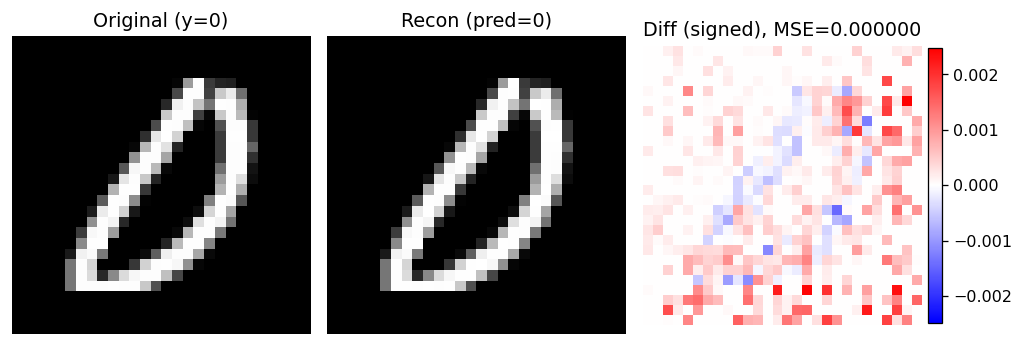

In [7]:
# recommended normalized-range for raw images in [0,1]
norm_min = (0.0 - MEAN) / STD
norm_max = (1.0 - MEAN) / STD

def _unnormalize_to_display(tensor):
    t = tensor.detach().cpu().clone()
    if t.dim() == 4:
        t = t[0]
    disp = t * STD + MEAN           # back to raw [0,1] approx
    disp = disp.squeeze(0).numpy()
    return np.clip(disp, 0.0, 1.0)

def plot_orig_recon_diff(orig, recon, orig_label=None, recon_label=None, figsize=(9,3)):
    orig_disp  = _unnormalize_to_display(orig)
    recon_disp = _unnormalize_to_display(recon)

    diff = recon_disp - orig_disp
    absdiff = np.abs(diff)
    mse = float((diff**2).mean())

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    axes[0].imshow(orig_disp, cmap='gray', vmin=0, vmax=1)
    axes[0].axis('off')
    axes[0].set_title(f'Original{f" (y={int(orig_label.item())})"}')

    axes[1].imshow(recon_disp, cmap='gray', vmin=0, vmax=1)
    axes[1].axis('off')
    if recon_label is not None:
        pred = recon_label
        axes[1].set_title(f'Recon (pred={pred})')
    else:
        axes[1].set_title('Reconstruction')

    im = axes[2].imshow(diff, cmap='bwr', vmin=-absdiff.max(), vmax=absdiff.max())
    axes[2].axis('off')
    axes[2].set_title(f'Diff (signed), MSE={mse:.6f}')
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()

    return mse

mse = plot_orig_recon_diff(img, recon_img, orig_label=label, recon_label=recon_label)

## Step 5 - Create Whole Reconstructed and Poisoned Dataset

In [8]:
# ---- Trigger definition ----
TRIGGER_SIZE  = 3
TRIGGER_POS   = (24, 24)   # bottom-right
TRIGGER_VAL   = 2.8
TARGET_CLASS  = 0
POISON_RATE   = 0.10 # changed from Dr. Saha's code

In [9]:
class PoisonedReconstructedDataset(Dataset):
    def __init__(self, poison_rate=POISON_RATE, target=TARGET_CLASS, transform=None):
        self.data        = []
        self.labels      = []
        self.is_poisoned = []
        self.transform   = transform
        self.n_poison    = 0

    # ------------------------------------------------------------------ #
    @classmethod
    def build(cls, train_loader, reconstruction_model, n_samples=200,
              poison_rate=POISON_RATE, target=TARGET_CLASS,
              dlg_iterations=200, transform=None):

        instance = cls(poison_rate=poison_rate, target=target, transform=transform)

        # --- 1. Collect n_samples from the loader ---
        all_data, all_labels = [], []
        for batch_data, batch_labels in train_loader:
            all_data.append(batch_data)
            all_labels.append(batch_labels)
            if sum(x.size(0) for x in all_data) >= n_samples:
                break
        all_data   = torch.cat(all_data,   dim=0)[:n_samples]
        all_labels = torch.cat(all_labels, dim=0)[:n_samples]

        # --- 2. Run DLG attack on each sample ---
        results = []
        for i in tqdm(range(n_samples), desc="DLG attack"):
            img   = all_data[i:i+1].to(device)
            label = all_labels[i:i+1].to(device)

            reconstruction_model.eval()
            optimizer = torch.optim.Adam(reconstruction_model.parameters(), lr=1e-3)
            optimizer.zero_grad()
            out  = reconstruction_model(img)
            loss = F.cross_entropy(out, label)
            loss.backward()
            target_grad = [p.grad.clone().detach() for p in reconstruction_model.parameters()]

            recon_img, recon_label = run_dlg_attack(
                model=reconstruction_model,
                target_gradients=target_grad,
                gt_data=img,
                iterations=dlg_iterations,
                verbose=False,
            )

            results.append({
                "index":         i,
                "orig_img":      img.detach().cpu(),
                "recon_img":     recon_img.detach().cpu(),
                "true_label":    label.item(),
                "recon_label":   recon_label,
                "label_correct": recon_label == label.item(),
            })

        # --- 3. Summary ---
        label_accuracy = sum(r["label_correct"] for r in results) / len(results)
        print(f"\nLabel recovery accuracy over {n_samples} samples: {label_accuracy:.2%}")

        # --- 4. Build poisoned dataset from results ---
        recon_images = [r["recon_img"].squeeze(0) for r in results]
        recon_labels = [r["recon_label"]           for r in results]

        non_target_indices = [i for i, lbl in enumerate(recon_labels) if lbl != target]
        n_poison           = int(len(non_target_indices) * poison_rate)
        poison_set         = set(np.random.choice(non_target_indices, n_poison, replace=False))

        for i, (img, label) in enumerate(zip(recon_images, recon_labels)):
            if i in poison_set:
                instance.data.append(instance._inject_trigger(img))
                instance.labels.append(target)
                instance.is_poisoned.append(True)
            else:
                instance.data.append(img)
                instance.labels.append(label)
                instance.is_poisoned.append(False)

        instance.n_poison = n_poison
        print(f"Dataset built: {len(instance.data)} samples, {instance.n_poison} poisoned.")
        return instance

    # ------------------------------------------------------------------ #
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img   = self.data[idx]
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

    def _inject_trigger(self, img):
        img    = img.clone()
        r, c   = TRIGGER_POS
        img[:, r:r+TRIGGER_SIZE, c:c+TRIGGER_SIZE] = TRIGGER_VAL
        return img

    # ------------------------------------------------------------------ #
    def save(self, path):
        torch.save({
            "data":        torch.stack(self.data),
            "labels":      torch.tensor(self.labels),
            "is_poisoned": torch.tensor(self.is_poisoned),
            "n_poison":    self.n_poison,
        }, path)
        print(f"Dataset saved to {path}  ({len(self.data)} samples)")

    @classmethod
    def load(cls, path, transform=None):
        checkpoint        = torch.load(path)
        instance          = cls.__new__(cls)
        instance.data         = list(checkpoint["data"])
        instance.labels       = checkpoint["labels"].tolist()
        instance.is_poisoned  = checkpoint["is_poisoned"].tolist()
        instance.n_poison     = checkpoint["n_poison"]
        instance.transform    = transform
        print(f"Dataset loaded from {path}  ({len(instance.data)} samples, {instance.n_poison} poisoned)")
        return instance

In [10]:
DATASET_PATH = "data/poisoned_recon_dataset.pt"
recon_poison_dataset = None

if os.path.exists(DATASET_PATH):
    print(f"Found existing dataset at '{DATASET_PATH}', loading...")
    recon_poison_dataset = PoisonedReconstructedDataset.load(DATASET_PATH)

else:
    print(f"No dataset found at '{DATASET_PATH}', running DLG attack...")
    recon_poison_dataset = PoisonedReconstructedDataset.build(
        train_loader=train_loader,
        reconstruction_model=reconstruction_model,
        n_samples=500,
        dlg_iterations=300,
    )
    recon_poison_dataset.save(DATASET_PATH)

Found existing dataset at 'data/poisoned_recon_dataset.pt', loading...
Dataset loaded from data/poisoned_recon_dataset.pt  (500 samples, 43 poisoned)


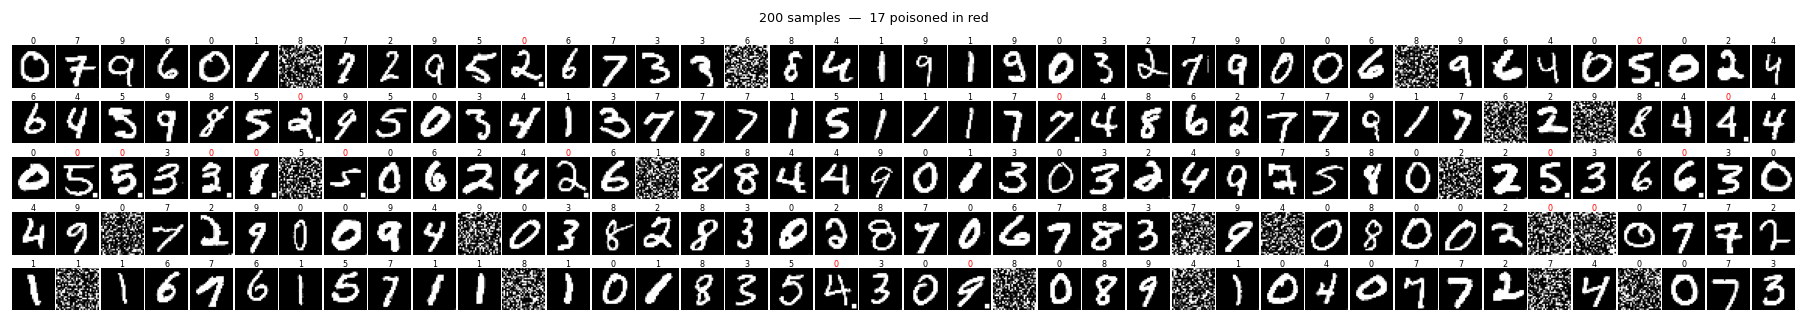

In [11]:
def plot_dataset(dataset):
    n    = min(200, len(dataset))
    cols = int(n / 5)
    rows = math.ceil(n / cols)
    n_poisoned = 0

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 0.5, rows * 0.6))
    axes = axes.flatten()

    for i in range(n):
        img, label = dataset[i]
        is_poisoned = dataset.is_poisoned[i]
        axes[i].imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[i].axis("off")
        axes[i].set_title(str(label), fontsize=5, pad=1,
                          color="red" if is_poisoned else "black")

        if is_poisoned:
            n_poisoned += 1

    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.subplots_adjust(wspace=0.05, hspace=0.3)
    plt.suptitle(
        f"{n} samples  —  {n_poisoned} poisoned in red",
        fontsize=8,
    )
    plt.savefig("dataset_grid.png", dpi=200, bbox_inches="tight")
    plt.show()

plot_dataset(recon_poison_dataset)

In [12]:
recon_poison_loader = DataLoader(recon_poison_dataset, batch_size=16, shuffle=True)

## Step 7 - Model Training

In [13]:
def train(model, train_loader, test_loader, epochs=10, label=""):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        # --- Train --- #
        model.train()
        total_loss = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()

        # --- Evaluate --- #
        model.eval()
        correct = 0
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            pred = model(imgs).argmax(1)
            correct += (pred == labels).sum().item()
        acc = correct / len(test_loader.dataset)

        # if epoch % 10 == 0:
        print(f"  {label} Epoch {epoch+1}/{epochs}  loss={total_loss/len(train_loader.dataset):.4f}  acc={acc:.2%}")
    return model

backdoor_model = train(reconstruction_model, recon_poison_loader, test_loader, epochs=10, label="[RECON-BACKDOOR-DATA]")

  [RECON-BACKDOOR-DATA] Epoch 1/10  loss=0.1371  acc=50.81%
  [RECON-BACKDOOR-DATA] Epoch 2/10  loss=0.0920  acc=70.69%
  [RECON-BACKDOOR-DATA] Epoch 3/10  loss=0.0573  acc=78.99%
  [RECON-BACKDOOR-DATA] Epoch 4/10  loss=0.0414  acc=79.38%
  [RECON-BACKDOOR-DATA] Epoch 5/10  loss=0.0313  acc=86.30%
  [RECON-BACKDOOR-DATA] Epoch 6/10  loss=0.0194  acc=87.79%
  [RECON-BACKDOOR-DATA] Epoch 7/10  loss=0.0125  acc=88.31%
  [RECON-BACKDOOR-DATA] Epoch 8/10  loss=0.0098  acc=88.76%
  [RECON-BACKDOOR-DATA] Epoch 9/10  loss=0.0085  acc=88.57%
  [RECON-BACKDOOR-DATA] Epoch 10/10  loss=0.0054  acc=88.59%


## Step 8 - Feature Extraction

In [14]:
def extract_layer_features(model, images, batch_size=128):
    """
    Run images through the model and collect activations from every hooked layer.

    Returns:
        dict[layer_name] → np.ndarray of shape (N, D)
        where D = channels (after global average pooling for conv layers)
    """
    model.eval()
    layer_features = {name: [] for name in model.LAYER_REGISTRY}

    with torch.no_grad():
        for i in range(0, len(images), batch_size):
            batch = images[i:i+batch_size].to(device)
            model(batch)
            acts = model.get_activations()

            for name, act in acts.items():
                if act.dim() == 4:               # Conv / BN: [B, C, H, W]
                    # Global Average Pooling over spatial dims → [B, C]
                    feat = act.mean(dim=[2, 3])
                else:                             # FC: [B, D]
                    feat = act
                layer_features[name].append(feat.numpy())

    return {name: np.vstack(v) for name, v in layer_features.items()}

In [29]:
imgs_collect = torch.stack([recon_poison_dataset[i][0] for i in range(len(recon_poison_dataset))])
labels_collect = np.array(recon_poison_dataset.labels)
truth_flags  = np.array(recon_poison_dataset.is_poisoned)

# print(f"Collected {len(recon_poison_dataset)} samples")
# print(f"   Genuine clean:  {(~truth_flags).sum()}")
# print(f"   Backdoored:     {truth_flags.sum()}")

# print("\nExtracting features from backdoor model (all layers)...")
# bd_layer_feats = extract_layer_features(backdoor_model, imgs_collect)

# --- filter to class 0 only ---
TARGET_CLASS = 0
class_mask    = (labels_collect == TARGET_CLASS)

imgs_collect  = imgs_collect[class_mask]
truth_flags   = truth_flags[class_mask]

print(f"Collected {class_mask.sum()} class-{TARGET_CLASS} samples")
print(f"   Genuine clean:  {(~truth_flags).sum()}")
print(f"   Backdoored:     {truth_flags.sum()}")

print("\nExtracting features from backdoor model (all layers)...")
bd_layer_feats = extract_layer_features(backdoor_model, imgs_collect)

print("\nFeature extraction complete")
for name, feat in bd_layer_feats.items():
    print(f"   {name:6s} → shape {feat.shape}")

Collected 105 class-0 samples
   Genuine clean:  62
   Backdoored:     43

Extracting features from backdoor model (all layers)...

Feature extraction complete
   conv1  → shape (105, 32)
   conv2  → shape (105, 64)
   conv3  → shape (105, 128)
   fc1    → shape (105, 256)
   fc2    → shape (105, 128)
   fc3    → shape (105, 10)


---
## 📐 Step 9 - Layer Significance Scoring

We compute **four complementary metrics** per layer:

| Metric | What it measures |
|--------|------------------|
| **Silhouette Score** | Cluster quality in PCA-2D space (−1 to +1, higher = better separation) |
| **Fisher Ratio** | Between-class variance / within-class variance (higher = more separable) |
| **KMeans Purity** | % of dominant true label in each detected cluster |
| **LDA Accuracy** | Linear discriminability — can a linear boundary separate clean from poisoned? |

In [30]:
def pca_reduce(features, n=50):
    n_components = min(n, features.shape[1], features.shape[0] - 1)
    return PCA(n_components=n_components, random_state=SEED).fit_transform(features)


def silhouette(features_2d, labels):
    """Silhouette score in 2D PCA space."""
    try:
        return silhouette_score(features_2d, labels)
    except:
        return 0.0


def fisher_ratio(features, labels):
    """
    Multivariate Fisher ratio: trace(S_B) / trace(S_W)
    S_B = between-class scatter, S_W = within-class scatter
    """
    classes = np.unique(labels)
    overall_mean = features.mean(axis=0)
    S_B = np.zeros((features.shape[1], features.shape[1]))
    S_W = np.zeros_like(S_B)

    for c in classes:
        X_c = features[labels == c]
        m_c = X_c.mean(axis=0)
        diff = (m_c - overall_mean).reshape(-1, 1)
        S_B += len(X_c) * (diff @ diff.T)
        X_centered = X_c - m_c
        S_W += X_centered.T @ X_centered

    sw_trace = np.trace(S_W)
    return np.trace(S_B) / (sw_trace + 1e-8)


def kmeans_purity(features_pca, labels, k=2):
    """
    Fit K-Means (k=2) and compute purity of each cluster.
    Returns mean purity across clusters.
    """
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    cluster_ids = km.fit_predict(features_pca)
    purity = 0.0
    for c in range(k):
        mask = cluster_ids == c
        if mask.sum() == 0: continue
        dominant = np.bincount(labels[mask].astype(int)).max()
        purity += dominant / mask.sum()
    return purity / k


def lda_accuracy(features_pca, labels):
    """
    Leave-out LDA: fit on 80%, predict 20%. Returns test accuracy.
    """
    from sklearn.model_selection import StratifiedShuffleSplit
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_idx, test_idx = next(sss.split(features_pca, labels))
    lda = LinearDiscriminantAnalysis()
    lda.fit(features_pca[train_idx], labels[train_idx])
    return lda.score(features_pca[test_idx], labels[test_idx])


# ---- Run all metrics across all layers ----
print("📐 Computing layer significance scores...\n")
print(f"{'Layer':>6}  {'Type':>4}  {'Silhouette':>10}  {'Fisher':>8}  {'KM-Purity':>9}  {'LDA-Acc':>8}")
print("-" * 58)

scores = {}
for name in bd_layer_feats:
    feats = bd_layer_feats[name]
    # Normalize features
    feats_norm = (feats - feats.mean(0)) / (feats.std(0) + 1e-8)
    feats_pca  = pca_reduce(feats_norm, n=50)
    feats_2d   = PCA(n_components=2, random_state=SEED).fit_transform(feats_norm)

    sil  = silhouette(feats_2d, truth_flags.astype(int))
    fr   = fisher_ratio(feats_pca, truth_flags)
    kp   = kmeans_purity(feats_pca, truth_flags)
    lda  = lda_accuracy(feats_pca, truth_flags)

    scores[name] = {'silhouette': sil, 'fisher': fr, 'purity': kp, 'lda': lda}
    meta = reconstruction_model.LAYER_META[name]
    print(f"{name:>6}  {meta['type']:>4}  {sil:>10.4f}  {fr:>8.4f}  {kp:>9.4f}  {lda:>8.4f}")

# Composite score: normalized sum of all four metrics
df_scores = pd.DataFrame(scores).T
for col in df_scores.columns:
    col_min, col_max = df_scores[col].min(), df_scores[col].max()
    df_scores[f'{col}_norm'] = (df_scores[col] - col_min) / (col_max - col_min + 1e-8)

norm_cols = [c for c in df_scores.columns if c.endswith('_norm')]
df_scores['composite'] = df_scores[norm_cols].mean(axis=1)
df_scores = df_scores.sort_values('composite', ascending=False)

BEST_LAYER  = df_scores.index[0]
WORST_LAYER = df_scores.index[-1]

print(f"\n🏆 Best separating layer:  {BEST_LAYER}  (composite={df_scores.loc[BEST_LAYER,'composite']:.4f})")
print(f"📉 Worst separating layer: {WORST_LAYER}  (composite={df_scores.loc[WORST_LAYER,'composite']:.4f})")

📐 Computing layer significance scores...

 Layer  Type  Silhouette    Fisher  KM-Purity   LDA-Acc
----------------------------------------------------------
 conv1  Conv      0.0109    0.0702     0.6422    0.6667
 conv2  Conv      0.0172    0.0640     0.5945    0.9524
 conv3  Conv      0.1065    0.1265     0.6055    1.0000
   fc1    FC      0.1576    0.1142     0.5731    1.0000
   fc2    FC      0.0907    0.0994     0.6021    1.0000
   fc3    FC      0.0392    0.0680     0.6000    0.8571

🏆 Best separating layer:  conv3  (composite=0.7800)
📉 Worst separating layer: conv1  (composite=0.2749)


---
## 📊 Step 10 - Layer Score Visualization

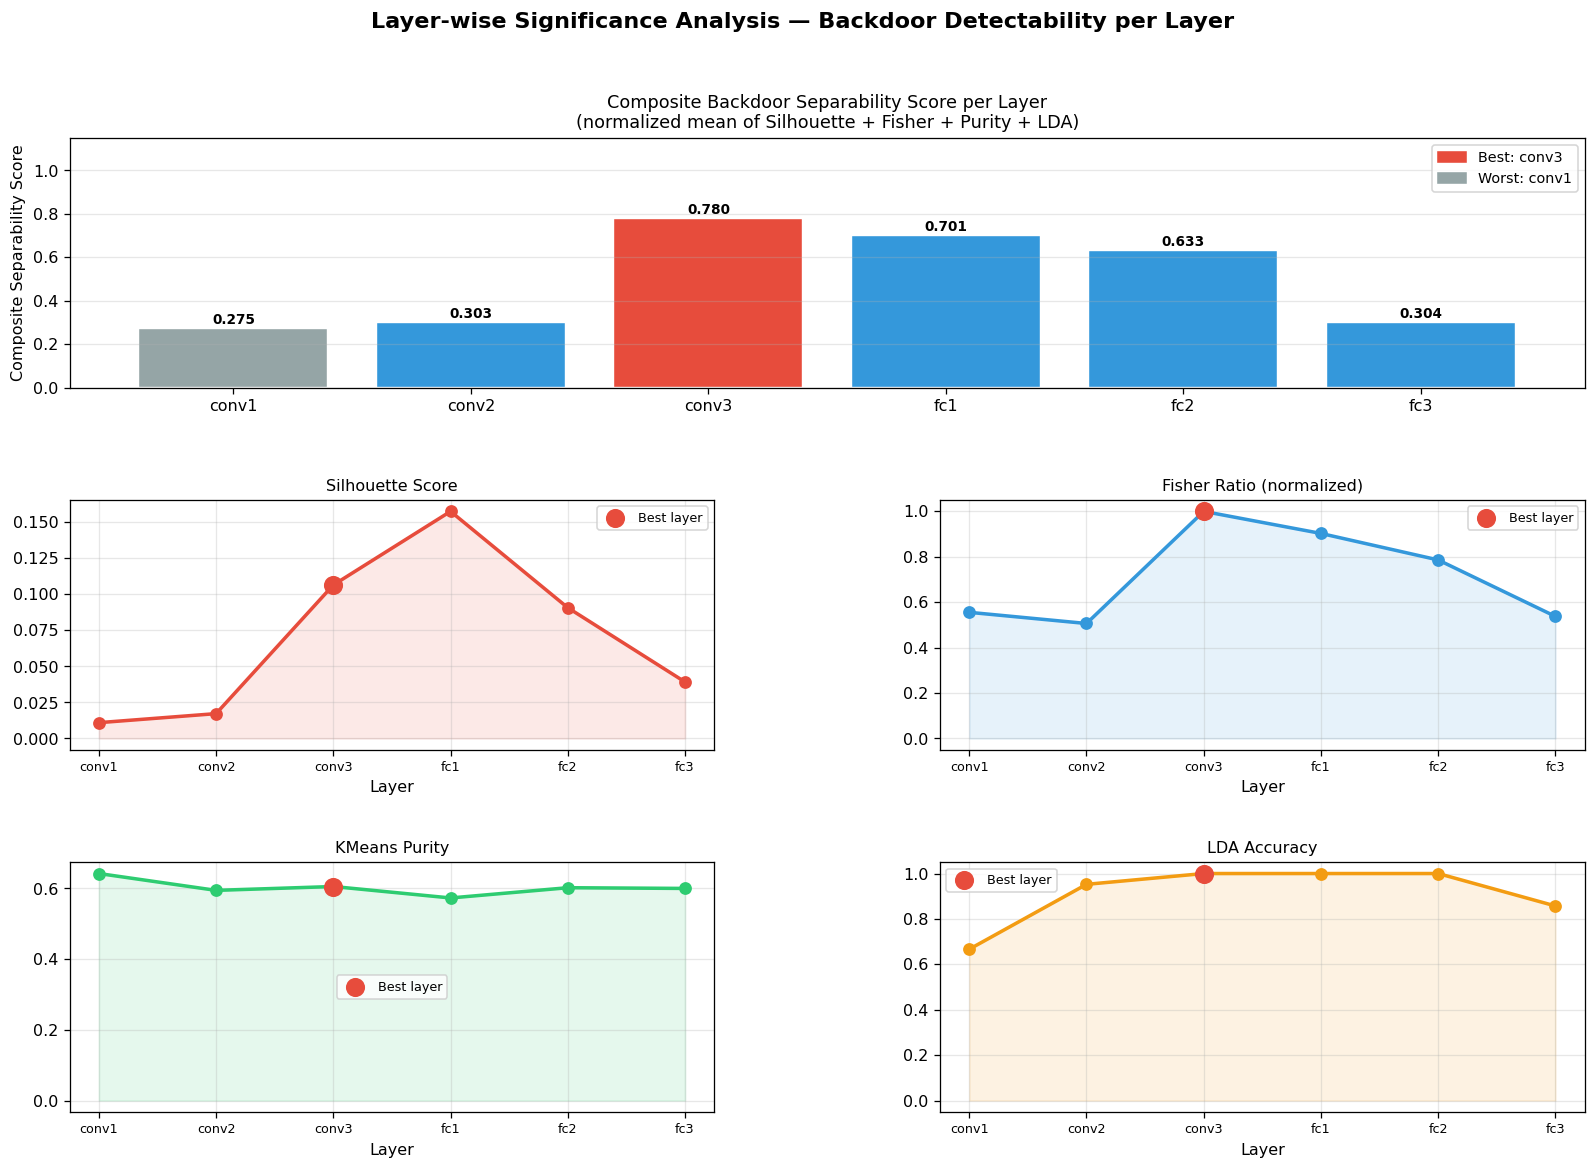

In [31]:
layers_ordered = list(reconstruction_model.LAYER_META.keys())  # keep network depth order
depths = [reconstruction_model.LAYER_META[l]['depth'] for l in layers_ordered]

metrics = ['silhouette', 'fisher', 'purity', 'lda']
metric_labels = ['Silhouette Score', 'Fisher Ratio (norm)', 'KMeans Purity', 'LDA Accuracy']
colors_m = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

# Normalize Fisher for fair plotting
df_plot = df_scores.loc[layers_ordered].copy()
fr_max = df_plot['fisher'].max()
df_plot['fisher_plot'] = df_plot['fisher'] / (fr_max + 1e-8)

fig = plt.figure(figsize=(17, 11))
gs  = gridspec.GridSpec(3, 2, hspace=0.45, wspace=0.35)
fig.suptitle(
    "Layer-wise Significance Analysis — Backdoor Detectability per Layer",
    fontsize=14, fontweight='bold'
)

# --- 1. Composite score bar ---
ax0 = fig.add_subplot(gs[0, :])
comp = [df_scores.loc[l, 'composite'] if l in df_scores.index else 0 for l in layers_ordered]
bar_colors = ['#e74c3c' if l == BEST_LAYER else
              '#95a5a6' if l == WORST_LAYER else '#3498db'
              for l in layers_ordered]
bars = ax0.bar(layers_ordered, comp, color=bar_colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, comp):
    ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val:.3f}", ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax0.set_ylabel("Composite Separability Score")
ax0.set_title("Composite Backdoor Separability Score per Layer\n"
              "(normalized mean of Silhouette + Fisher + Purity + LDA)",
              fontsize=11)
ax0.set_ylim(0, 1.15)
best_patch  = mpatches.Patch(color='#e74c3c', label=f'Best: {BEST_LAYER}')
worst_patch = mpatches.Patch(color='#95a5a6', label=f'Worst: {WORST_LAYER}')
ax0.legend(handles=[best_patch, worst_patch], fontsize=9)
ax0.grid(axis='y', alpha=0.3)

# --- 2-5. Individual metric line plots ---
plot_keys = ['silhouette', 'fisher_plot', 'purity', 'lda']
plot_lbls = ['Silhouette Score', 'Fisher Ratio (normalized)', 'KMeans Purity', 'LDA Accuracy']
positions = [gs[1,0], gs[1,1], gs[2,0], gs[2,1]]

for pos, key, lbl, col in zip(positions, plot_keys, plot_lbls, colors_m):
    ax = fig.add_subplot(pos)
    vals = [df_plot.loc[l, key] if key in df_plot.columns else
            df_plot.loc[l, key.replace('_plot', '')] for l in layers_ordered]
    ax.plot(layers_ordered, vals, marker='o', linewidth=2.2, color=col, markersize=7)
    ax.fill_between(layers_ordered, vals, alpha=0.12, color=col)

    # Highlight best
    best_val = df_plot.loc[BEST_LAYER, key] if key in df_plot.columns else df_plot.loc[BEST_LAYER, key.replace('_plot','')]
    ax.scatter([BEST_LAYER], [best_val], color='#e74c3c', s=120, zorder=5, label='Best layer')

    ax.set_title(lbl, fontsize=10)
    ax.set_xlabel("Layer")
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

# plt.savefig('layer_significance_scores.png', dpi=130, bbox_inches='tight')
plt.show()
# print(f"\n💾 Saved: layer_significance_scores.png")

---
## 🗺️ Step 11 - 2D Clustering — Best Layer vs Penultimate Layer vs Worst Layer

> Three projection methods: **PCA**, **t-SNE**, **LDA** (supervised projection for reference)
> Applied to three layers so you can see the stark difference in separability.

In [32]:
PENULTIMATE_LAYER = 'conv3'  # the layer AC typically uses
COMPARE_LAYERS = [BEST_LAYER, PENULTIMATE_LAYER, WORST_LAYER]
COMPARE_LABELS = [
    f'Best Layer ({BEST_LAYER})',
    f'Penultimate ({PENULTIMATE_LAYER})',
    f'Worst Layer ({WORST_LAYER})'
]

def project_2d(features, method='pca', labels=None):
    feats_norm = (features - features.mean(0)) / (features.std(0) + 1e-8)
    feats_pca  = pca_reduce(feats_norm, n=min(50, feats_norm.shape[1]))

    if method == 'pca':
        proj = PCA(n_components=2, random_state=SEED).fit_transform(feats_norm)
    elif method == 'tsne':
        proj = TSNE(n_components=2, perplexity=35, random_state=SEED,
                    max_iter=1200, verbose=0).fit_transform(feats_pca)
    elif method == 'lda':
        lda = LinearDiscriminantAnalysis(n_components=1)
        lda.fit(feats_pca, labels)
        proj_1d = lda.transform(feats_pca)
        # Add jitter on y-axis for 2D display
        proj = np.hstack([proj_1d, np.random.randn(len(proj_1d), 1) * 0.3])
    return proj


def scatter_with_clusters(ax, proj_2d, truth, km_labels, title, show_legend=False):
    """Scatter plot with ground truth markers and K-Means cluster background."""
    # K-Means decision boundary shading
    x_min, x_max = proj_2d[:, 0].min() - 1, proj_2d[:, 0].max() + 1
    y_min, y_max = proj_2d[:, 1].min() - 1, proj_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]

    km = KMeans(n_clusters=2, random_state=SEED, n_init=10).fit(proj_2d)
    Z = km.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.10, colors=['#3498db', '#e74c3c'])
    ax.contour(xx,  yy, Z, colors=['gray'], linewidths=0.8, linestyles='--', alpha=0.4)

    # Points: color by ground truth, marker by K-Means cluster
    markers = ['o', 's']
    gt_colors = {0: '#2980b9', 1: '#c0392b'}  # 0=clean, 1=poisoned
    for gt in [0, 1]:
        for km_c in [0, 1]:
            mask = (truth == gt) & (km_labels == km_c)
            if mask.sum() == 0: continue
            ax.scatter(proj_2d[mask, 0], proj_2d[mask, 1],
                       c=gt_colors[gt], marker=markers[km_c],
                       s=18, alpha=0.7, edgecolors='none')

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel("Component 1"); ax.set_ylabel("Component 2")
    ax.grid(alpha=0.2)

    if show_legend:
        handles = [
            mpatches.Patch(color='#2980b9', label='Clean (GT)'),
            mpatches.Patch(color='#c0392b', label='Poisoned (GT)'),
            plt.Line2D([0], [0], marker='o', color='gray', label='KM cluster A', linestyle='None'),
            plt.Line2D([0], [0], marker='s', color='gray', label='KM cluster B', linestyle='None'),
        ]
        ax.legend(handles=handles, fontsize=7.5, loc='upper right')


print("🗺️ Projecting features to 2D with PCA, t-SNE, LDA...\n(t-SNE may take ~60s)")

# Pre-compute projections
projections = {}
for layer in COMPARE_LAYERS:
    feats = bd_layer_feats[layer]
    feats_norm = (feats - feats.mean(0)) / (feats.std(0) + 1e-8)
    feats_pca  = pca_reduce(feats_norm)
    km_labels  = KMeans(n_clusters=2, random_state=SEED, n_init=10).fit_predict(feats_pca)

    projections[layer] = {
        'pca':   project_2d(feats, method='pca'),
        'tsne':  project_2d(feats, method='tsne'),
        'lda':   project_2d(feats, method='lda', labels=truth_flags.astype(int)),
        'km':    km_labels
    }
    print(f"  ✅ {layer} done")

print("✅ All projections computed")

🗺️ Projecting features to 2D with PCA, t-SNE, LDA...
(t-SNE may take ~60s)
  ✅ conv3 done
  ✅ conv3 done
  ✅ conv1 done
✅ All projections computed


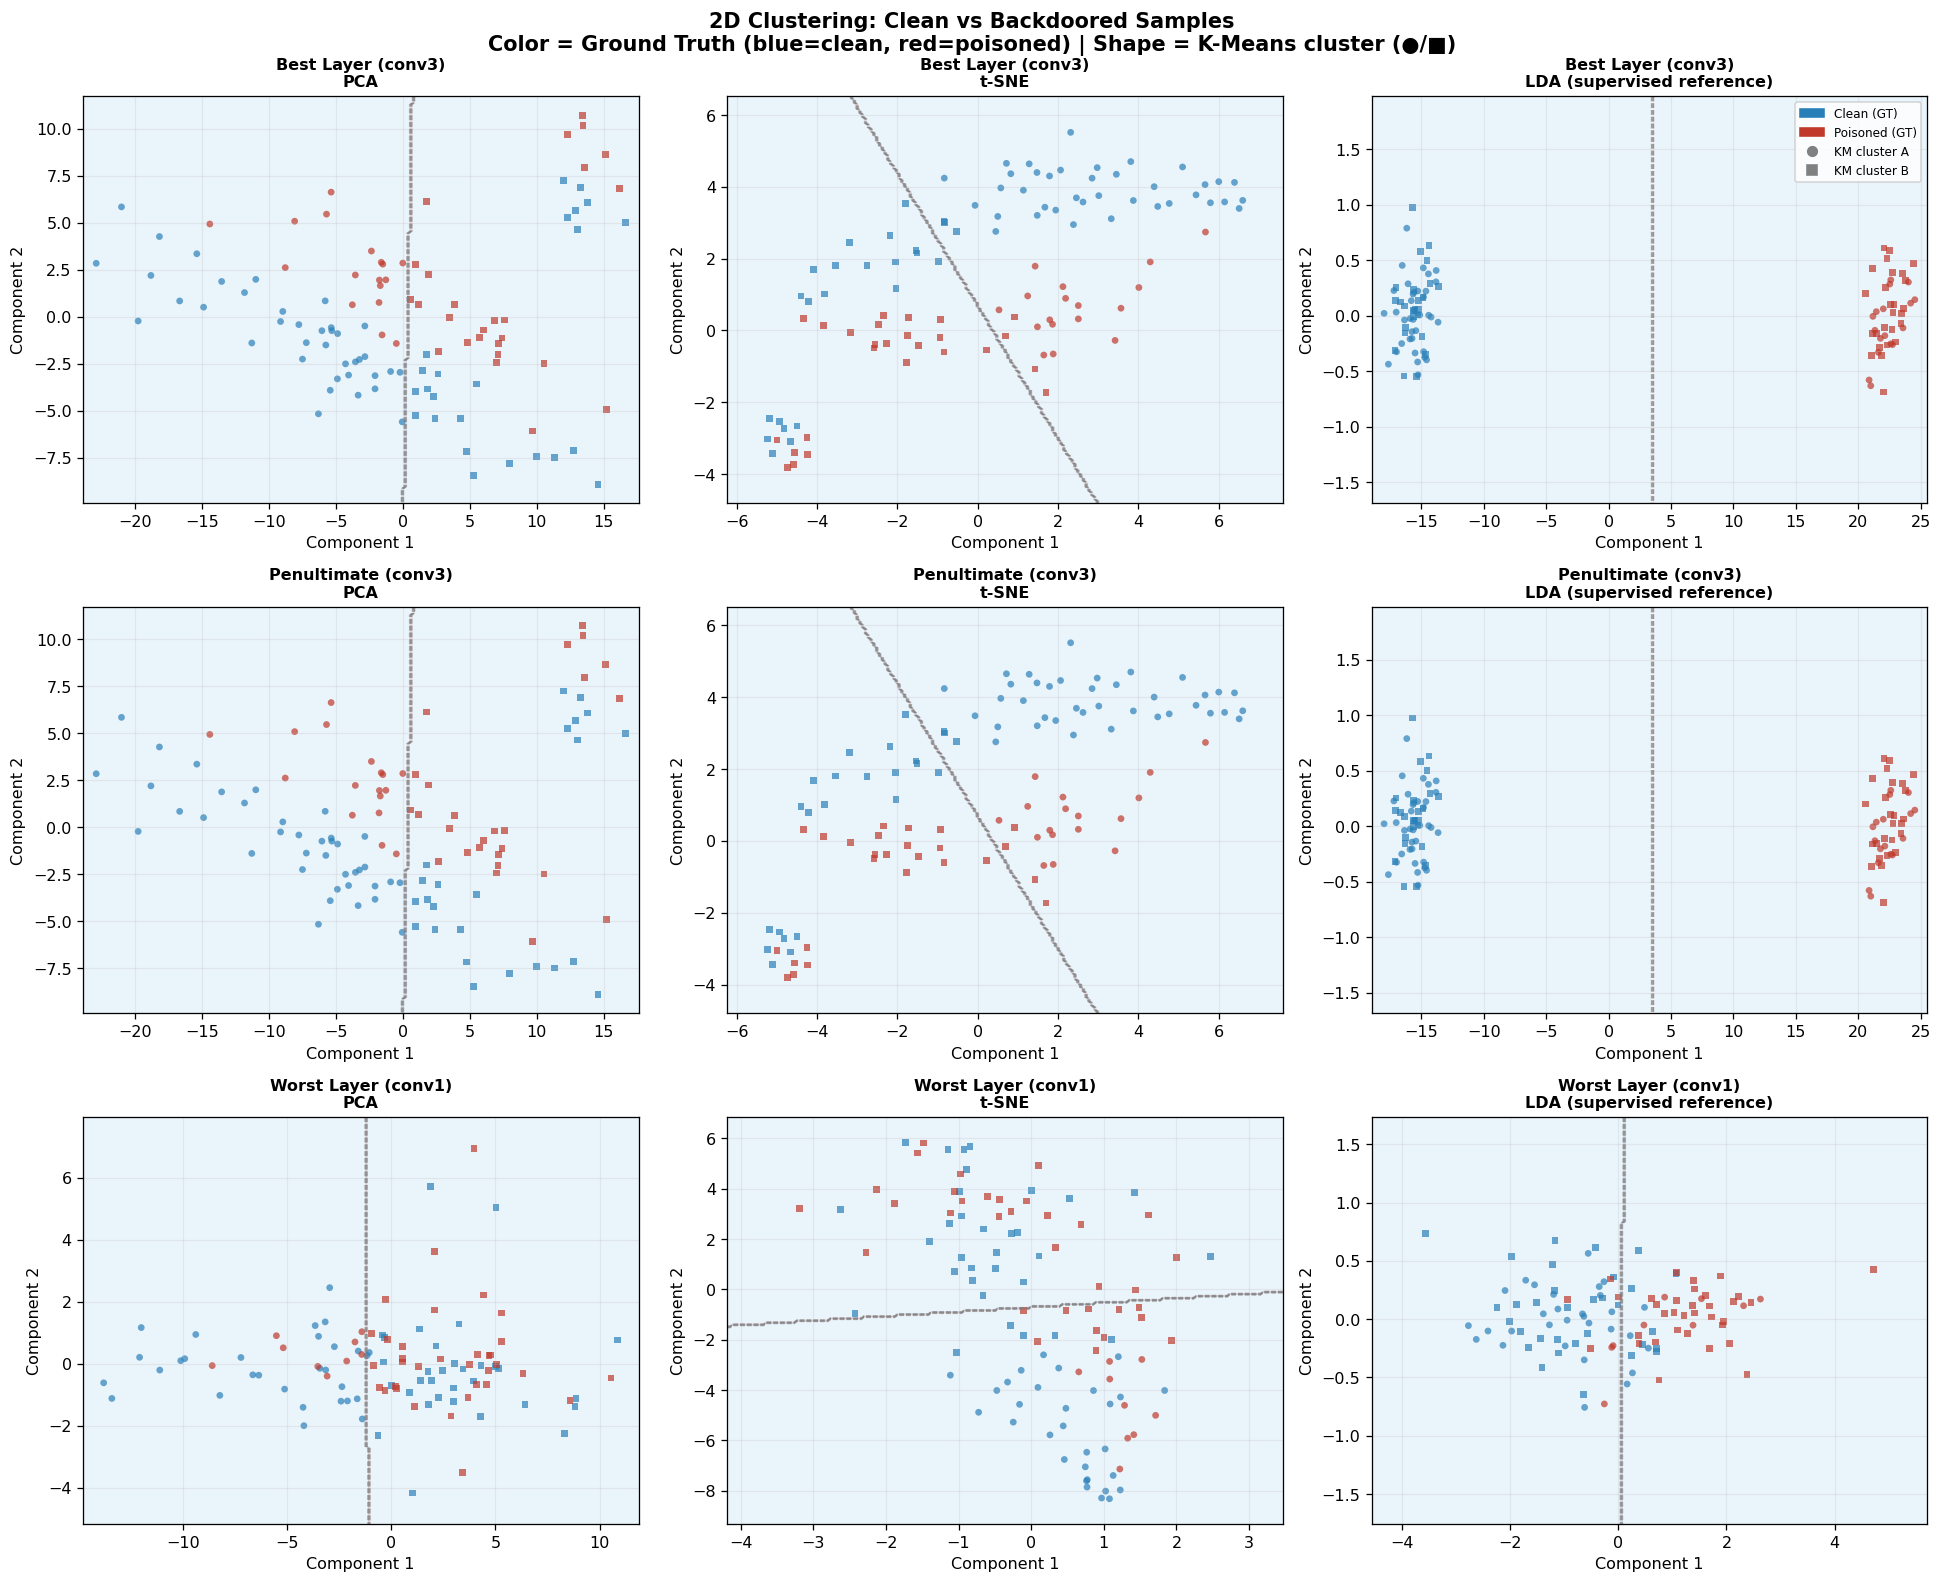

In [33]:
fig, axes = plt.subplots(3, 3, figsize=(17, 14))
fig.suptitle(
    "2D Clustering: Clean vs Backdoored Samples\n"
    "Color = Ground Truth (blue=clean, red=poisoned) | Shape = K-Means cluster (●/■)",
    fontsize=13, fontweight='bold'
)

methods = ['pca', 'tsne', 'lda']
method_names = ['PCA', 't-SNE', 'LDA (supervised reference)']

for row, (layer, layer_lbl) in enumerate(zip(COMPARE_LAYERS, COMPARE_LABELS)):
    for col, (method, method_name) in enumerate(zip(methods, method_names)):
        ax = axes[row, col]
        proj  = projections[layer][method]
        km    = projections[layer]['km']
        title = f"{layer_lbl}\n{method_name}"
        scatter_with_clusters(ax, proj, truth_flags, km, title, show_legend=(row==0 and col==2))

plt.tight_layout()
plt.show()

In [34]:
# ---- Cell A: Build standard poisoned dataset (no reconstruction) ----
class PoisonedDataset(Dataset):
    def __init__(self, clean_dataset, n_samples=None, poison_rate=POISON_RATE, target=TARGET_CLASS):
        self.data, self.labels, self.is_poisoned = [], [], []

        # Slice to n_samples first if specified
        indices = list(range(n_samples if n_samples else len(clean_dataset)))

        non_target = [i for i in indices if clean_dataset.targets[i] != target]
        poison_set = set(np.random.choice(
            non_target, int(len(non_target) * poison_rate), replace=False))

        for i in indices:
            img, label = clean_dataset[i]
            if i in poison_set:
                img = self._inject_trigger(img)
                self.data.append(img)
                self.labels.append(target)
                self.is_poisoned.append(True)
            else:
                self.data.append(img)
                self.labels.append(label)
                self.is_poisoned.append(False)

        self.n_poison = len(poison_set)
        print(f"Standard poisoned dataset: {len(self.data)} samples, {self.n_poison} poisoned.")

    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx], self.labels[idx]

    def _inject_trigger(self, img):
        img = img.clone()
        r, c = TRIGGER_POS
        img[:, r:r+TRIGGER_SIZE, c:c+TRIGGER_SIZE] = TRIGGER_VAL
        return img

N = len(recon_poison_dataset)
standard_poison_full = PoisonedDataset(train_raw, n_samples=N)
standard_poison_loader = DataLoader(standard_poison_full, batch_size=16, shuffle=True)

print(f"Recon dataset size:    {len(recon_poison_dataset)}")
print(f"Standard dataset size: {len(standard_poison_full)}")

Standard poisoned dataset: 500 samples, 45 poisoned.
Recon dataset size:    500
Standard dataset size: 500


In [35]:
# ---- Cell B: Train model on standard poisoned data ----
standard_poison_model  = LargeCNN().to(device)
standard_poison_model  = train(standard_poison_model, standard_poison_loader,
                               test_loader, epochs=10, label="[STANDARD-POISON]")

  [STANDARD-POISON] Epoch 1/10  loss=0.1260  acc=59.33%
  [STANDARD-POISON] Epoch 2/10  loss=0.0693  acc=76.40%
  [STANDARD-POISON] Epoch 3/10  loss=0.0370  acc=81.21%
  [STANDARD-POISON] Epoch 4/10  loss=0.0193  acc=84.86%
  [STANDARD-POISON] Epoch 5/10  loss=0.0128  acc=86.98%
  [STANDARD-POISON] Epoch 6/10  loss=0.0063  acc=86.54%
  [STANDARD-POISON] Epoch 7/10  loss=0.0031  acc=87.46%
  [STANDARD-POISON] Epoch 8/10  loss=0.0028  acc=87.67%
  [STANDARD-POISON] Epoch 9/10  loss=0.0022  acc=87.96%
  [STANDARD-POISON] Epoch 10/10  loss=0.0015  acc=88.02%


In [36]:
# ---- Cell C: Extract features from both datasets via both models ----

# Reconstructed poisoned dataset
imgs_recon   = torch.stack([recon_poison_dataset[i][0] for i in range(N)])
flags_recon  = np.array(recon_poison_dataset.is_poisoned[:N])

# Standard poisoned dataset (same N samples)
imgs_std     = torch.stack([standard_poison_full[i][0] for i in range(N)])
flags_std    = np.array(standard_poison_full.is_poisoned[:N])

# Features: each dataset through its own trained model
feats_recon  = extract_layer_features(backdoor_model,        imgs_recon)
feats_std    = extract_layer_features(standard_poison_model, imgs_std)

print("Feature shapes (should match):")
for name in feats_recon:
    print(f"  {name}: recon={feats_recon[name].shape}  std={feats_std[name].shape}")

Feature shapes (should match):
  conv1: recon=(500, 32)  std=(500, 32)
  conv2: recon=(500, 64)  std=(500, 64)
  conv3: recon=(500, 128)  std=(500, 128)
  fc1: recon=(500, 256)  std=(500, 256)
  fc2: recon=(500, 128)  std=(500, 128)
  fc3: recon=(500, 10)  std=(500, 10)


In [37]:
# ---- Cell D: Compute scores for both datasets ----
def compute_scores(layer_feats, truth_flags):
    scores = {}
    for name, feats in layer_feats.items():
        feats_norm = (feats - feats.mean(0)) / (feats.std(0) + 1e-8)
        feats_pca  = pca_reduce(feats_norm, n=50)
        feats_2d   = PCA(n_components=2, random_state=SEED).fit_transform(feats_norm)
        scores[name] = {
            'silhouette': silhouette(feats_2d, truth_flags.astype(int)),
            'fisher':     fisher_ratio(feats_pca, truth_flags),
            'purity':     kmeans_purity(feats_pca, truth_flags),
            'lda':        lda_accuracy(feats_pca, truth_flags),
        }
    df = pd.DataFrame(scores).T
    for col in ['silhouette', 'purity', 'lda']:
        df[col + '_norm'] = (df[col] - df[col].min()) / (df[col].max() - df[col].min() + 1e-8)
    fr_max = df['fisher'].max()
    df['fisher_norm'] = df['fisher'] / (fr_max + 1e-8)
    df['composite'] = df[['silhouette_norm','fisher_norm','purity_norm','lda_norm']].mean(axis=1)
    return df

df_recon = compute_scores(feats_recon, flags_recon)
df_std   = compute_scores(feats_std,   flags_std)

# Delta: positive = reconstruction IMPROVES detectability, negative = hurts it
df_delta = df_recon[['silhouette','fisher','purity','lda','composite']] \
         - df_std  [['silhouette','fisher','purity','lda','composite']]

print("\nComposite score comparison (higher = more detectable):")
print(pd.DataFrame({'standard': df_std['composite'],
                    'recon':    df_recon['composite'],
                    'delta':    df_delta['composite']}).round(4).to_string())


Composite score comparison (higher = more detectable):
       standard   recon   delta
conv1    0.3257  0.2693 -0.0564
conv2    0.5422  0.5693  0.0271
conv3    0.6320  0.6462  0.0142
fc1      0.5927  0.7270  0.1343
fc2      0.7500  0.7500  0.0000
fc3      0.5047  0.6440  0.1393


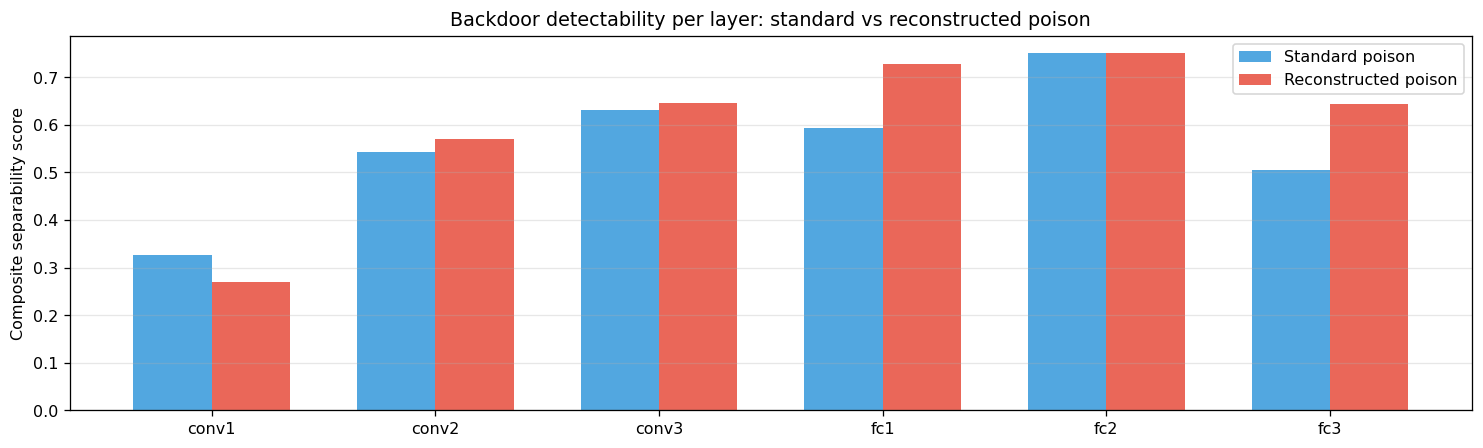

In [38]:
# ---- Cell E: Plot B — composite bar chart side by side ----
layers = list(reconstruction_model.LAYER_META.keys())
x      = np.arange(len(layers))
w      = 0.35

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(x - w/2, df_std['composite'].loc[layers],   w, label='Standard poison',       color='#3498db', alpha=0.85)
ax.bar(x + w/2, df_recon['composite'].loc[layers], w, label='Reconstructed poison',  color='#e74c3c', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(layers)
ax.set_ylabel("Composite separability score")
ax.set_title("Backdoor detectability per layer: standard vs reconstructed poison")
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

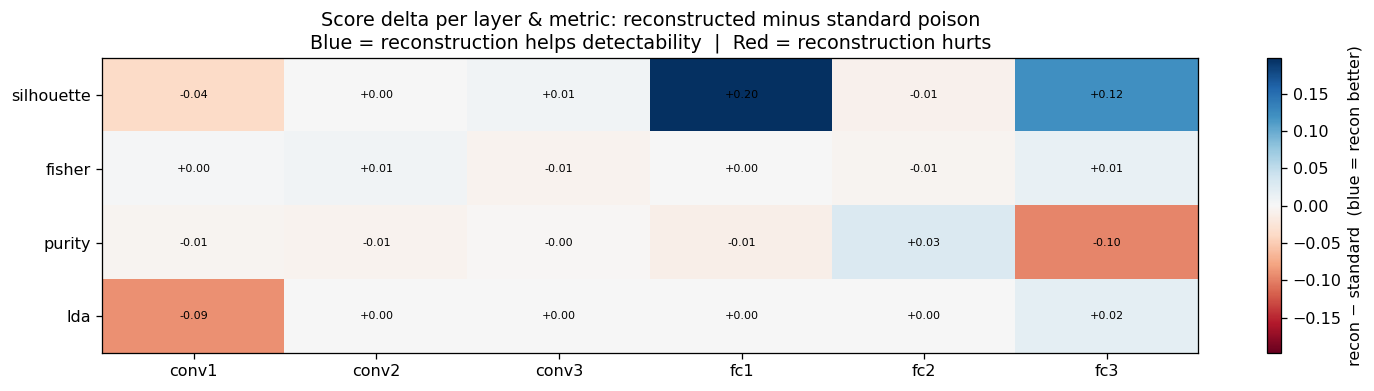

In [39]:
# ---- Cell F: Plot C — delta heatmap ----
metrics      = ['silhouette', 'fisher', 'purity', 'lda']
delta_matrix = df_delta[metrics].loc[layers].T.values

fig, ax = plt.subplots(figsize=(13, 3.5))
im = ax.imshow(delta_matrix, cmap='RdBu', aspect='auto',
               vmin=-np.abs(delta_matrix).max(),
               vmax= np.abs(delta_matrix).max())
ax.set_xticks(range(len(layers)));   ax.set_xticklabels(layers)
ax.set_yticks(range(len(metrics)));  ax.set_yticklabels(metrics)
fig.colorbar(im, ax=ax, label='recon − standard  (blue = recon better)')
ax.set_title("Score delta per layer & metric: reconstructed minus standard poison\n"
             "Blue = reconstruction helps detectability  |  Red = reconstruction hurts")
for i in range(len(metrics)):
    for j in range(len(layers)):
        ax.text(j, i, f"{delta_matrix[i,j]:+.2f}", ha='center', va='center', fontsize=7)
plt.tight_layout(); plt.show()

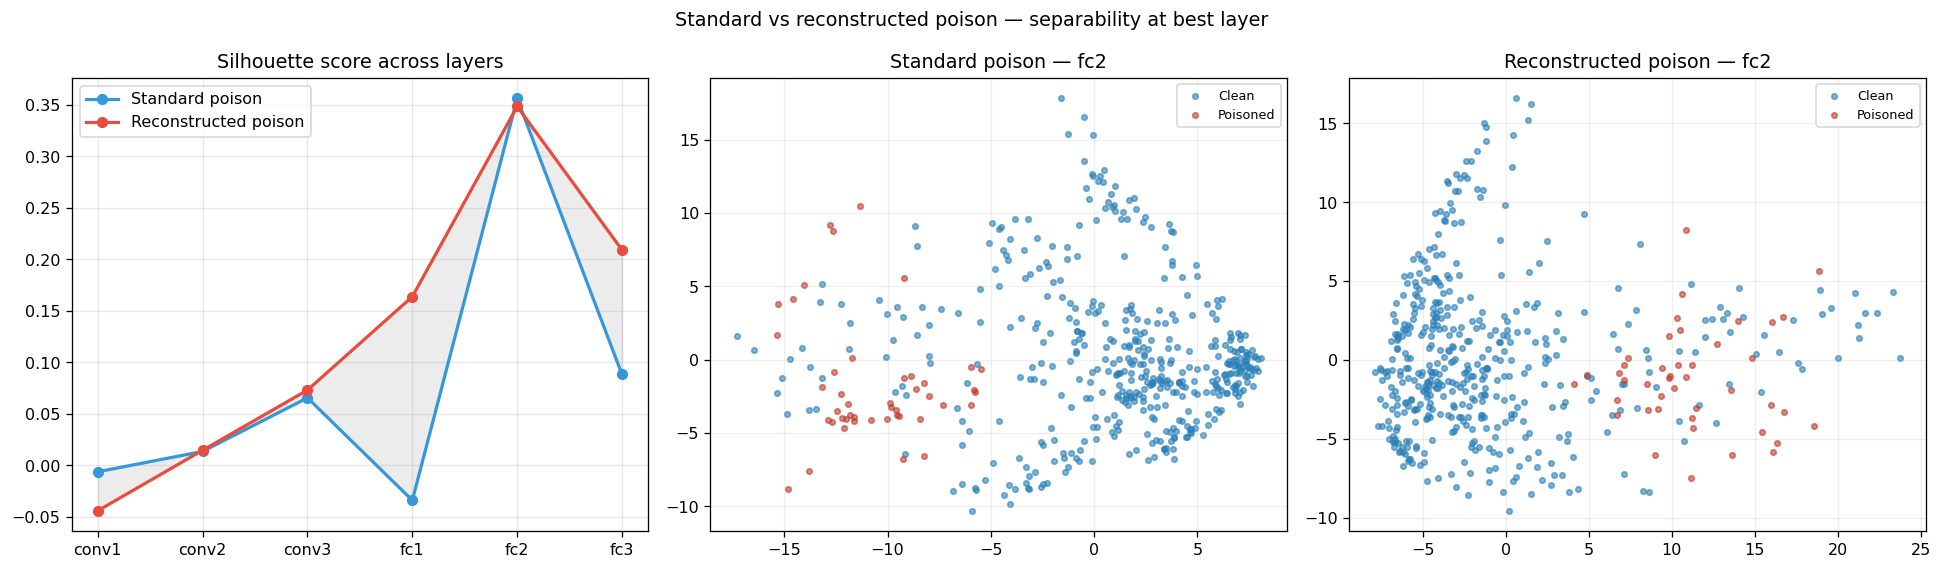

In [40]:
# ---- Cell G: Plot D — silhouette profile + scatter comparison ----
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Left: silhouette line plot
axes[0].plot(layers, df_std['silhouette'].loc[layers],
             marker='o', label='Standard poison', color='#3498db', linewidth=2)
axes[0].plot(layers, df_recon['silhouette'].loc[layers],
             marker='o', label='Reconstructed poison', color='#e74c3c', linewidth=2)
axes[0].fill_between(layers,
    df_std['silhouette'].loc[layers],
    df_recon['silhouette'].loc[layers],
    alpha=0.15, color='gray')
axes[0].set_title("Silhouette score across layers"); axes[0].legend(); axes[0].grid(alpha=0.3)

# Middle: best layer scatter — standard
best_layer = df_std['composite'].idxmax()
feats_std_best   = feats_std[best_layer]
feats_recon_best = feats_recon[best_layer]

for ax, feats, flags, title in [
    (axes[1], feats_std_best,   flags_std,   f"Standard poison — {best_layer}"),
    (axes[2], feats_recon_best, flags_recon, f"Reconstructed poison — {best_layer}"),
]:
    fn = (feats - feats.mean(0)) / (feats.std(0) + 1e-8)
    p2 = PCA(n_components=2, random_state=SEED).fit_transform(fn)
    ax.scatter(p2[~flags, 0], p2[~flags, 1], c='#2980b9', s=12, alpha=0.6, label='Clean')
    ax.scatter(p2[ flags, 0], p2[ flags, 1], c='#c0392b', s=12, alpha=0.6, label='Poisoned')
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(alpha=0.2)

plt.suptitle("Standard vs reconstructed poison — separability at best layer", fontsize=12)
plt.tight_layout(); plt.show()

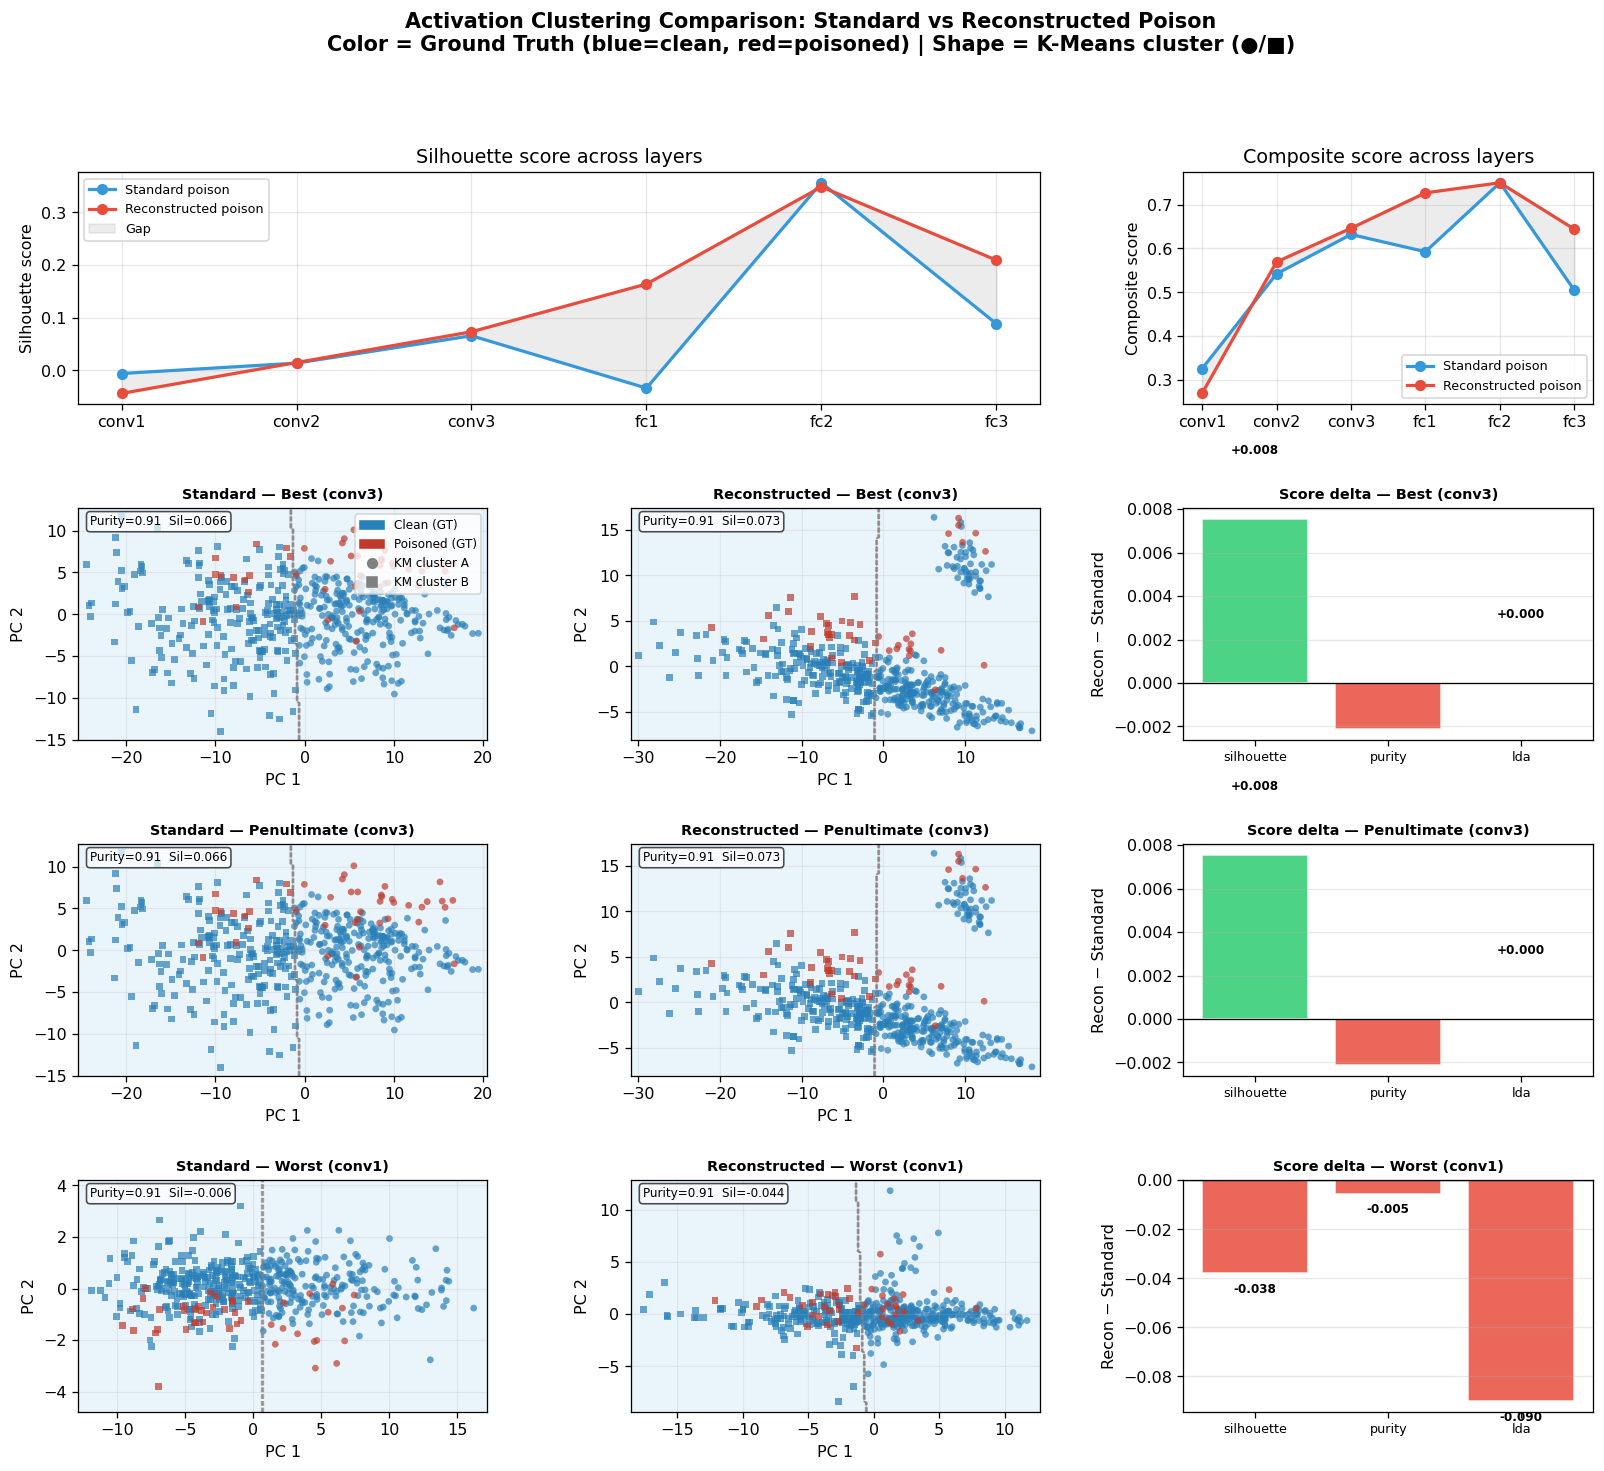

In [41]:
# ---- Cell G: Full comparison scatter grid with K-Means decision boundaries ----

COMPARE_LAYERS = [BEST_LAYER, PENULTIMATE_LAYER, WORST_LAYER]
COMPARE_LABELS = [
    f'Best ({BEST_LAYER})',
    f'Penultimate ({PENULTIMATE_LAYER})',
    f'Worst ({WORST_LAYER})',
]

def scatter_comparison(ax, feats, flags, title, show_legend=False):
    """PCA scatter with K-Means decision boundary — mirrors your existing scatter_with_clusters."""
    fn   = (feats - feats.mean(0)) / (feats.std(0) + 1e-8)
    p2   = PCA(n_components=2, random_state=SEED).fit_transform(fn)
    km   = KMeans(n_clusters=2, random_state=SEED, n_init=10).fit(p2)

    # --- K-Means decision boundary shading ---
    x_min, x_max = p2[:, 0].min() - 1, p2[:, 0].max() + 1
    y_min, y_max = p2[:, 1].min() - 1, p2[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = km.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.10, colors=['#3498db', '#e74c3c'])
    ax.contour(xx, yy, Z, colors=['gray'], linewidths=0.8, linestyles='--', alpha=0.4)

    # --- Points: color = ground truth, shape = K-Means cluster ---
    km_labels  = km.labels_
    markers    = ['o', 's']
    gt_colors  = {False: '#2980b9', True: '#c0392b'}
    gt_names   = {False: 'Clean', True: 'Poisoned'}
    for gt in [False, True]:
        for km_c in [0, 1]:
            mask = (flags == gt) & (km_labels == km_c)
            if mask.sum() == 0: continue
            ax.scatter(p2[mask, 0], p2[mask, 1],
                       c=gt_colors[gt], marker=markers[km_c],
                       s=18, alpha=0.7, edgecolors='none',
                       label=f'{gt_names[gt]} / KM-{km_c}' if show_legend else None)

    # --- K-Means purity annotation ---
    purity = kmeans_purity(p2, flags.astype(int))
    sil    = silhouette_score(p2, flags.astype(int))
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
    ax.text(0.03, 0.97, f"Purity={purity:.2f}  Sil={sil:.3f}",
            transform=ax.transAxes, fontsize=7.5, va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
    ax.grid(alpha=0.2)
    if show_legend:
        handles = [
            mpatches.Patch(color='#2980b9', label='Clean (GT)'),
            mpatches.Patch(color='#c0392b', label='Poisoned (GT)'),
            plt.Line2D([0],[0], marker='o', color='gray', linestyle='None', label='KM cluster A'),
            plt.Line2D([0],[0], marker='s', color='gray', linestyle='None', label='KM cluster B'),
        ]
        ax.legend(handles=handles, fontsize=7.5, loc='upper right')


# --- Layout: rows = layers, cols = [silhouette line | standard scatter | recon scatter] ---
fig = plt.figure(figsize=(17, 14))
gs  = gridspec.GridSpec(4, 3, hspace=0.45, wspace=0.35)
fig.suptitle(
    "Activation Clustering Comparison: Standard vs Reconstructed Poison\n"
    "Color = Ground Truth (blue=clean, red=poisoned) | Shape = K-Means cluster (●/■)",
    fontsize=13, fontweight='bold'
)

# --- Row 0: silhouette + fisher line plots spanning all 3 cols ---
ax_sil = fig.add_subplot(gs[0, :2])
ax_sil.plot(layers, df_std['silhouette'].loc[layers],
            marker='o', label='Standard poison', color='#3498db', linewidth=2)
ax_sil.plot(layers, df_recon['silhouette'].loc[layers],
            marker='o', label='Reconstructed poison', color='#e74c3c', linewidth=2)
ax_sil.fill_between(layers,
    df_std['silhouette'].loc[layers],
    df_recon['silhouette'].loc[layers],
    alpha=0.15, color='gray', label='Gap')
ax_sil.set_title("Silhouette score across layers")
ax_sil.legend(fontsize=8); ax_sil.grid(alpha=0.3)
ax_sil.set_ylabel("Silhouette score")

ax_comp = fig.add_subplot(gs[0, 2])
ax_comp.plot(layers, df_std['composite'].loc[layers],
             marker='o', label='Standard poison', color='#3498db', linewidth=2)
ax_comp.plot(layers, df_recon['composite'].loc[layers],
             marker='o', label='Reconstructed poison', color='#e74c3c', linewidth=2)
ax_comp.fill_between(layers,
    df_std['composite'].loc[layers],
    df_recon['composite'].loc[layers],
    alpha=0.15, color='gray')
ax_comp.set_title("Composite score across layers")
ax_comp.legend(fontsize=8); ax_comp.grid(alpha=0.3)
ax_comp.set_ylabel("Composite score")

# --- Rows 1-3: one row per compare layer, col 0=standard col 1=recon col 2=delta inset ---
for row_idx, (layer, layer_lbl) in enumerate(zip(COMPARE_LAYERS, COMPARE_LABELS)):
    ax_std  = fig.add_subplot(gs[row_idx + 1, 0])
    ax_rec  = fig.add_subplot(gs[row_idx + 1, 1])
    ax_bar  = fig.add_subplot(gs[row_idx + 1, 2])

    scatter_comparison(ax_std, feats_std[layer],  flags_std,   f"Standard — {layer_lbl}",
                       show_legend=(row_idx == 0))
    scatter_comparison(ax_rec, feats_recon[layer], flags_recon, f"Reconstructed — {layer_lbl}",
                       show_legend=False)

    # Per-layer metric delta bar chart in col 2
    metrics_plot = ['silhouette', 'purity', 'lda']
    deltas = [df_delta.loc[layer, m] for m in metrics_plot]
    bar_colors = ['#2ecc71' if d >= 0 else '#e74c3c' for d in deltas]
    ax_bar.bar(metrics_plot, deltas, color=bar_colors, alpha=0.85, edgecolor='white')
    ax_bar.axhline(0, color='black', linewidth=0.8)
    ax_bar.set_title(f"Score delta — {layer_lbl}", fontsize=9, fontweight='bold')
    ax_bar.set_ylabel("Recon − Standard")
    ax_bar.tick_params(axis='x', labelsize=8)
    ax_bar.grid(axis='y', alpha=0.3)
    for i, (m, d) in enumerate(zip(metrics_plot, deltas)):
        ax_bar.text(i, d + (0.003 if d >= 0 else -0.008),
                    f"{d:+.3f}", ha='center', fontsize=7.5, fontweight='bold')

plt.savefig("comparison_clustering.png", dpi=130, bbox_inches='tight')
plt.show()